In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import matplotlib.pyplot as plt
from matplotlib import colors

import sys
sys.path.append("../src")

import netket as nk

from netket.experimental.dynamics import RK45

from callbacks import (
    get_tdvp_monitor_callback,
    get_umbrella_monitor_callback,
)

from logger import Logger

W0218 14:30:21.105428 1902469 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W0218 14:30:21.107576 1902356 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
/mnt/home/rwiersema/blurred_sampling/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


∣NK⟩ Tip: On GPUs an efficient choice is to run ~512 Markov Chains per GPU.

In [30]:
import jax.numpy as jnp
import numpy as np
import flax.linen as nn

L = 2
N = L**2
J0 = 1.0
hilbert = nk.hilbert.Spin(s=1 / 2, N=N)

graph = nk.graph.Grid((L, L), pbc=False)
hamiltonian = nk.operator.Heisenberg(hilbert, graph, J=1/4)

def get_vstate(n_samples):
    model = nk.models.RBM(param_dtype=complex, alpha=1 / N)
    sampler = nk.sampler.MetropolisLocal(hilbert, n_chains=n_samples)
    model = nk.models.RBM(
        alpha=1,
        param_dtype=complex,
        use_visible_bias=True,
        hidden_bias_init=nn.initializers.normal(1e-4),
        visible_bias_init=nn.initializers.normal(1e-4),
        kernel_init=nn.initializers.normal(1e-4),
    )
    return nk.vqs.MCState(
        sampler=sampler, model=model, n_samples=n_samples, seed=100, sampler_seed=100
    )
def get_vstate_parameters(n_samples):
    vstate= get_vstate(n_samples)

    # Thermalize
    for i in range(0):
        vstate.sample(n_samples=n_samples)
    e0 = nk.exact.lanczos_ed(hamiltonian)

    gs = nk.driver.VMC_SR(
        hamiltonian,
        optimizer=nk.optimizer.Sgd(0.01),
        variational_state=vstate,
        diag_shift=1e-4,
    )
    gs.run(1000, callback=lambda s, l, d: d._loss_stats.mean > e0 + 1e-3)
    return vstate.parameters

vstate = get_vstate(2**10)
parameters = get_vstate_parameters(2**10)
vstate.parameters = parameters.copy()
e0 = nk.exact.lanczos_ed(hamiltonian)
estimated_e = vstate.expect(hamiltonian)
print(f"GS energy {e0}")
print(f"variational energy {estimated_e}")


Automatic SR implementation choice:  QGT


 16%|█▌        | 158/1000 [00:00<00:04, 209.62it/s, Energy=-1.99905+0.00001j ± 0.00095 [σ²=9.3e-04]]


GS energy [-2.]
variational energy -1.9950-0.0000j ± 0.0022 [σ²=5.0e-03]


In [55]:
graph = nk.graph.Chain(N, pbc=True)

deltaJ = -2
vertical_bonds = []
for x in range(L):
    for y in range(L - 1):
        i = x * L + y
        j = x * L + (y + 1)
        vertical_bonds.append((i, j))
vertical_bonds_graph = nk.graph.Graph(edges=vertical_bonds)
vertical_heisenberg = nk.operator.Heisenberg(hilbert,  vertical_bonds_graph, J=deltaJ/4)
quench_hamiltonian = hamiltonian + vertical_heisenberg
single_edge = nk.graph.Graph(edges=(vertical_bonds[0],))
s_correlator = nk.operator.Heisenberg(hilbert, single_edge, J=1./4)

fields_to_track = (
    ("t", "values"),
    ("dt", "values"),
    ("Generator", "Mean"),
    ("Generator", "Variance"),
    ("s_corr", "Mean"),
    ("s_corr", "Variance"),
    ("r_squared", "values"),
    # Umbrella/bridge monitoring fields
    ("ess_bridge", "values"),
    ("snr_min", "values"),
    ("snr_10p", "values"),
    ("snr_med", "values"),
    ("snrF_min", "values"),
    ("snrF_med", "values"),
    ("q_bridge", "values"),
    # Per-step SNRs from OVar
    ("snr", "values"),
    ("snr_F", "values"),
)


def measure_corr(step, log, driver):
    log['s_corr'] = driver.state.expect(s_correlator)
    return True

# Exact dynamics

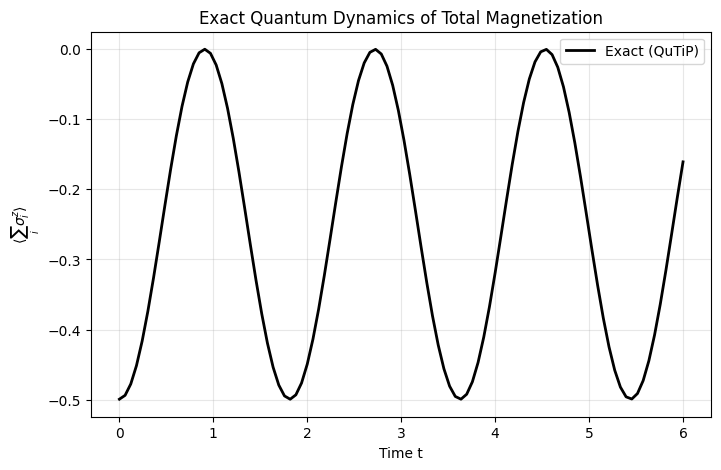

Initial magnetization: -0.498859
Final magnetization: -0.161162


In [56]:
import qutip as qt

# Get the Hamiltonian matrix from netket
H_matrix = quench_hamiltonian.to_dense()

# Convert to QuTiP Qobj
H_qutip = qt.Qobj(H_matrix)

# Get initial state from vstate
vstate = get_vstate(2**10)
vstate.parameters = parameters.copy()
psi0_array = vstate.to_array()
psi0_qutip = qt.Qobj(psi0_array)
psi0_qutip = psi0_qutip.unit()  # Normalize

# Create total magnetization operator (sum of Z_i)
# Convert to QuTiP
Scorr_qutip = qt.Qobj(s_correlator.to_dense() )

# Time evolution parameters
T = 1.5*4
times_exact = np.linspace(0.0, T, 100)

# Evolve the state and calculate expectation values
magnetizations_exact = []
for t in times_exact:
    # Evolve state
    psi_t = (-1j * H_qutip * t).expm() * psi0_qutip
    # Calculate expectation value
    corr = qt.expect(Scorr_qutip, psi_t)
    magnetizations_exact.append(corr)

# Plot the exact dynamics
plt.figure(figsize=(8, 5))
plt.plot(times_exact, np.real(magnetizations_exact), 'k-', linewidth=2, label='Exact (QuTiP)')
plt.xlabel('Time t')
plt.ylabel(r'$\langle \sum_i \sigma^z_i \rangle$')
plt.title('Exact Quantum Dynamics of Total Magnetization')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Initial magnetization: {np.real(magnetizations_exact[0]):.6f}")
print(f"Final magnetization: {np.real(magnetizations_exact[-1]):.6f}")

## Standard Dynamics

In [ ]:
from schmitt_tdvp_bridge import TDVPSchmittBridge
from schmitt_tdvp import TDVPSchmitt


def fit_bridge(n_samples_tvmc):
    T = 1.5 * 4
    q = 0.5
    save_times = np.linspace(0.0, T, 20)
    exp_name = f"bridge_{n_samples_tvmc}_DeltaJ_{deltaJ:1.2f}_q_{q:1.2f}"
    # Make sure we always start with the same state in notebook

    save_path = f"./data/HEISENBERG_{N}/{exp_name}/"

    logger = Logger(path=save_path, fields=fields_to_track)
    if logger.restore():
        if logger.done:
            print("Data exists, skipping...")
            return
    if not os.path.exists(save_path):
        os.makedirs(save_path)

    vstate = get_vstate(n_samples_tvmc)
    vstate.parameters = parameters.copy()
    for i in range(100):
        vstate.sample()
    callbacks = []
    callbacks.append(measure_corr)
    if q==0:
        tdvp_monitor_callback = get_tdvp_monitor_callback(save_times, save_path)
    else:
        tdvp_monitor_callback = get_umbrella_monitor_callback(save_times, save_path)
    callbacks.append(tdvp_monitor_callback)

    integrator = RK45(1e-3, adaptive=False, rtol=1e-6, dt_limits=(1e-5, 1e-2))
    tvmc_kwargs = {}
    if q == 0:
        driver = TDVPSchmitt(
            quench_hamiltonian,
            vstate,
            integrator,
            t0=0,
            holomorphic=False,
            snr_atol=2,
            rcond=1e-14,
            rcond_smooth=1e-10,
            **tvmc_kwargs,
        )
    else:
        driver = TDVPSchmittBridge(
            quench_hamiltonian,
            vstate,
            integrator,
            t0=0,
            q=q,
            holomorphic=False,
            snr_atol=2,
            rcond=1e-14,
            rcond_smooth=1e-10,
            **tvmc_kwargs,
        )

    driver.run(
        T,
        out=logger,
        callback=callbacks,
        show_progress=True,
        timeit=True,
    )
    logger.flush(vstate, done=True)

In [75]:
fit_bridge(2**10)

100%|██████████| 6.00/6.00 [05:29<00:00, 54.9s/it, n=6000, Generator=-0.071-0.214j ± 0.054 [σ²=3.0e+00]]


╭────────────────────────────────────────────── Timing Information ───────────────────────────────────────────────╮
│ Total: 331.927                                                                                                  │
│ ├── (2.2%) | MCState.expect : 7.314 s                                                                           │
│ │   └── (24.4%) | MCState.sample : 1.788 s                                                                      │
│ │       └── (45.0%) | sampling n_discarded samples : 0.804 s                                                    │
│ ├── (18.0%) | MCState.sample : 59.696 s                                                                         │
│ │   └── (66.9%) | sampling n_discarded samples : 39.960 s                                                       │
│ ├── (5.0%) | QGTJacobian_DefaultConstructor : 16.672 s                                                          │
│ │   └── (32.6%) | jacobian : 5.427 s                                  

Restored: True
Restored: True


/mnt/home/rwiersema/blurred_sampling/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/mnt/home/rwiersema/blurred_sampling/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/tmp/ipykernel_1902356/2153788918.py:19: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k-" (-> linestyle='-'). The keyword argument will take precedence.
  ax_z.plot(times_exact, np.real(magnetizations_exact), 'k-', linewidth=2, label='ED', linestyle='dashed')


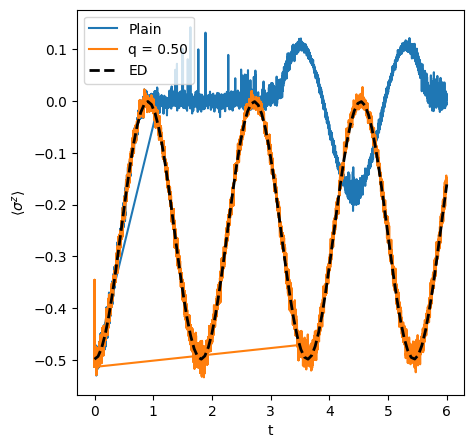

In [77]:
fig, ax_z = plt.subplots(1, 1, figsize=(5, 5))
q=0
exp_name = f"bridge_{2**10}_DeltaJ_{deltaJ:1.2f}_q_{q:1.2f}"
save_path = f"./data/HEISENBERG_{N}/{exp_name}/"
logger = Logger(path=save_path, fields=fields_to_track)
print("Restored:", logger.restore())
ax_z.plot(logger.data["t"]["values"], logger.data["s_corr"]["Mean"], label = f"Plain", zorder=-1)

q=0.5
exp_name = f"bridge_{2**10}_DeltaJ_{deltaJ:1.2f}_q_{q:1.2f}"
save_path = f"./data/HEISENBERG_{N}/{exp_name}/"
logger = Logger(path=save_path, fields=fields_to_track)
print("Restored:", logger.restore())
ax_z.plot(logger.data["t"]["values"], logger.data["s_corr"]["Mean"], label = f"q = {0.5:1.2f}", zorder=-1)

ax_z.set_xlabel("t")
ax_z.set_ylabel(r"$\langle\sigma^z \rangle$")

ax_z.plot(times_exact, np.real(magnetizations_exact), 'k-', linewidth=2, label='ED', linestyle='dashed')
ax_z.legend()



Restored: True


/tmp/ipykernel_544605/3580412476.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_snr.legend(loc="best")
/mnt/home/rwiersema/blurred_sampling/.venv/lib/python3.11/site-packages/matplotlib/scale.py:255: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)
/tmp/ipykernel_544605/3580412476.py:71: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_snrF.legend(loc="best")


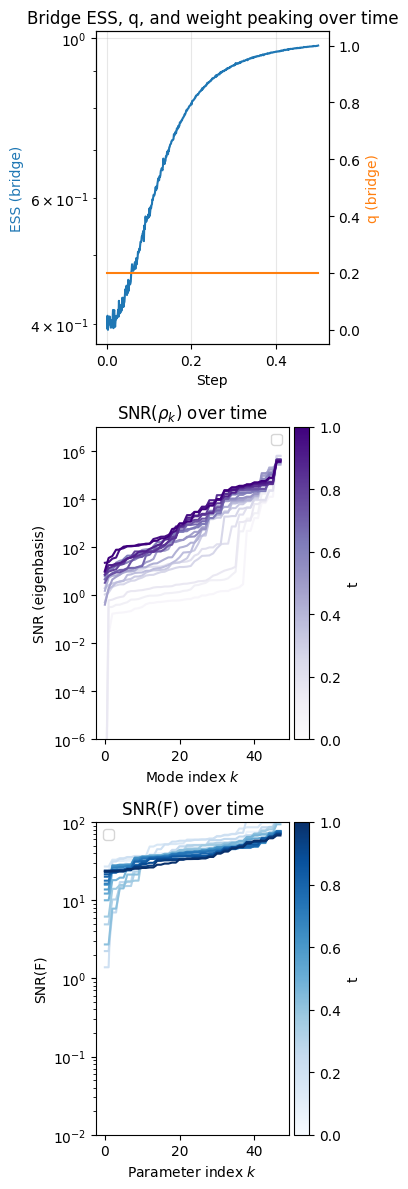

In [ ]:
n_samples_tvmc = 2**12
fig, (ax_essq,ax_snr,ax_snrF) = plt.subplots(3, 1, figsize=(4, 12))
exp_name = f"bridge_{n_samples_tvmc}"
save_path = f"./data/TFIM_EPS_{N}/{exp_name}/"
logger = Logger(path=save_path, fields=fields_to_track)
print("Restored:", logger.restore())

x_vals = logger.data["t"]["values"]
ess_vals = logger.data["ess_bridge"]["values"]
q_vals = logger.data["q_bridge"]["values"]
if ess_vals and q_vals:


    ax_right = ax_essq.twinx()
    (line1,) = ax_essq.plot(
        x_vals, ess_vals, color="tab:blue", label="ESS (bridge)"
    )
    # Also plot max_weight_over_mean on left axis
    (line2,) = ax_right.plot(
        x_vals, q_vals, color="tab:orange", label="q (bridge)"
    )

    ax_essq.set_xlabel("Step")
    ax_essq.set_ylabel("ESS (bridge)", color="tab:blue")
    ax_right.set_ylabel("q (bridge)", color="tab:orange")
    ax_essq.set_yscale('log')
    ax_right.set_ylim(-0.05, 1.05)
    ax_essq.grid(True, alpha=0.3)
    ax_essq.set_title("Bridge ESS, q, and weight peaking over time")

    lines = [line1, line2]
    labels = [l.get_label() for l in lines]

# Top-left: SNR (eigenbasis) sorted curves with log y; add median and min lines
snr_len = len(logger.data.get("snr", {}).get("values", []))
cmap_snr = plt.get_cmap("Purples")
# Normalize step index to [0,1] for colorbar
norm_frac = colors.Normalize(vmin=0.0, vmax=1.0)
for i in range(snr_len):
    snr_data = np.array(logger.data["snr"]["values"][i]).flatten()
    frac = 0.0 if snr_len <= 1 else i / (snr_len - 1)
    snr_data = np.nan_to_num(snr_data, 0.)
    ax_snr.plot(np.sort(snr_data), color=cmap_snr(norm_frac(frac)))
# if len(snr_min_series) > 0:
#     ax_snr.axhline(np.array(snr_min_series)[-1], color="gray", linestyle=":", label="min")
ax_snr.set_xlabel(r"Mode index $k$")
ax_snr.set_ylabel("SNR (eigenbasis)")
ax_snr.set_title(rf"SNR($\rho_k$) over time")
ax_snr.set_yscale("log")
ax_snr.set_ylim([1e-6, 1e7])
ax_snr.legend(loc="best")
# Add colorbar for normalized step [0,1]
sm_snr = plt.cm.ScalarMappable(cmap=cmap_snr, norm=norm_frac)
sm_snr.set_array([])
fig.colorbar(sm_snr, ax=ax_snr, pad=0.02, label="t")

# Top-middle: SNR(F) sorted curves with log y; add median and min lines
snrF_len = len(logger.data.get("snr_F", {}).get("values", []))
cmap_snrF = plt.get_cmap("Blues")
for i in range(snrF_len):
    snr_F_data = np.array(logger.data["snr_F"]["values"][i]).flatten()
    snr_F_data = np.nan_to_num(snr_F_data, 0.)
    frac = 0.0 if snrF_len <= 1 else i / (snrF_len - 1)
    ax_snrF.plot(np.sort(snr_F_data), color=cmap_snrF(norm_frac(frac)))
# if len(snrF_min_series) > 0:
#     ax_snrF.axhline(np.array(snrF_min_series)[-1], color="gray", linestyle=":", label="min")
ax_snrF.set_xlabel(r"Parameter index $k$")
ax_snrF.set_ylabel("SNR(F)")
ax_snrF.set_title(rf"SNR(F) over time")
ax_snrF.set_yscale("log")
ax_snrF.set_ylim([1e-2, 1e2])
ax_snrF.legend(loc="best")
# Add colorbar for normalized step [0,1]
sm_snrF = plt.cm.ScalarMappable(cmap=cmap_snrF, norm=norm_frac)
sm_snrF.set_array([])
fig.colorbar(sm_snrF, ax=ax_snrF, pad=0.02, label="t")
plt.tight_layout()



Restored: True


NameError: name 'norm_frac' is not defined

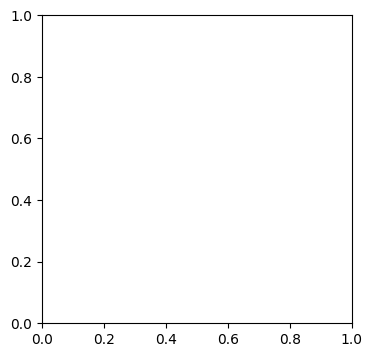

In [ ]:
n_samples_tvmc = 2**12
fig, ax_snrF = plt.subplots(1, 1, figsize=(4, 4))
exp_name = f"fixed_{n_samples_tvmc}"
save_path = f"./data/TFIM_EPS_{N}/{exp_name}/"
logger = Logger(path=save_path, fields=fields_to_track)
print("Restored:", logger.restore())

# Top-middle: SNR(F) sorted curves with log y; add median and min lines
snrF_len = len(logger.data.get("snr_F", {}).get("values", []))
cmap_snrF = plt.get_cmap("Blues")
for i in range(snrF_len):
    snr_F_data = np.array(logger.data["snr_F"]["values"][i]).flatten()
    snr_F_data = np.nan_to_num(snr_F_data, 0.)
    frac = 0.0 if snrF_len <= 1 else i / (snrF_len - 1)
    ax_snrF.plot(np.sort(snr_F_data), color=cmap_snrF(norm_frac(frac)))
# if len(snrF_min_series) > 0:
ax_snrF.set_xlabel(r"Parameter index $k$")
ax_snrF.set_ylabel("SNR(F)")
ax_snrF.set_title(rf"SNR(F) over time")
ax_snrF.set_yscale("log")
ax_snrF.set_ylim([1e-2, 1e2])
ax_snrF.legend(loc="best")
# Add colorbar for normalized step [0,1]
sm_snrF = plt.cm.ScalarMappable(cmap=cmap_snrF, norm=norm_frac)
sm_snrF.set_array([])
fig.colorbar(sm_snrF, ax=ax_snrF, pad=0.02, label="t")
plt.tight_layout()

# Using the exact QGT

In [106]:
from schmitt_tdvp_bridge_exact_qgt import TDVPSchmittBridgeExactQGT

def fit_bridge(n_samples_tvmc):
    T = 0.5
    save_times = np.linspace(0.0, T, 20)
    exp_name = f"bridge_{n_samples_tvmc}"
    # Make sure we always start with the same state in notebook

    save_path = f"./data/TFIM_EPS_{N}_EXACT_QGT/{exp_name}/"

    logger = Logger(path=save_path, fields=fields_to_track)
    if logger.restore():
        if logger.done:
            print("Data exists, skipping...")
            return
    if not os.path.exists(save_path):
        os.makedirs(save_path)
    
    vstate = get_vstate(n_samples_tvmc)
    print(vstate.expect(sigma_zs))
    callbacks = [ ]
    callbacks.append(measure_sigma_z)
    tdvp_monitor_callback = get_umbrella_monitor_callback(save_times, save_path)
    callbacks.append(tdvp_monitor_callback)

    integrator = RK45(1e-3, adaptive=False, rtol=1e-4, dt_limits=(1e-4, 1e-2))
    tvmc_kwargs = {}
    driver = TDVPSchmittBridgeExactQGT(
        hamiltonian,
        vstate,
        integrator,
        t0=0,
        q=0.5,
        holomorphic=False,
        snr_atol=2,
        rcond=1e-14,
        rcond_smooth=1e-10,
            **tvmc_kwargs,
        )

    driver.run(
        T,
        out=logger,
        callback = callbacks,
        show_progress=True,
        timeit=True,
    )
    logger.flush(vstate, done=True)

fit_bridge(2**12)

-5.00e-01+0.00e+00j ± nan [σ²=0.0e+00]


100%|██████████| 0.50/0.50 [00:33<00:00, 67.2s/it, n=500, Generator=0.096-0.025j ± 0.025 [σ²=2.6e+00]]      


╭────────────────────────────────────────────── Timing Information ───────────────────────────────────────────────╮
│ Total: 33.631                                                                                                   │
│ ├── (1.1%) | MCState.expect : 0.356 s                                                                           │
│ ├── (18.5%) | MCState.sample : 6.205 s                                                                          │
│ │   └── (69.2%) | sampling n_discarded samples : 4.292 s                                                        │
│ ├── (9.4%) | QGTJacobian_DefaultConstructor : 3.164 s                                                           │
│ │   └── (61.4%) | jacobian : 1.944 s                                                                            │
│ └── (15.2%) | _impl : 5.108 s                                                                                   │
╰───────────────────────────────────────────────────────────────────────

File not found
Restored: False
File not found
Restored: False
File not found
Restored: False
Restored: True
File not found
Restored: False
File not found
Restored: False


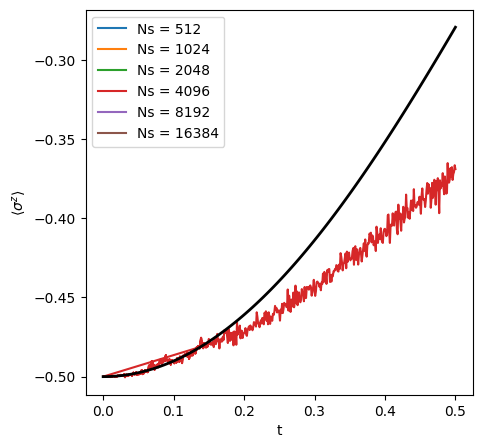

In [107]:
fig, ax_z = plt.subplots(1, 1, figsize=(5, 5))
for n_samples in n_samples_list:
    exp_name = f"bridge_{n_samples}"
    save_path = f"./data/TFIM_EPS_{N}_EXACT_QGT/{exp_name}/"
    logger = Logger(path=save_path, fields=fields_to_track)
    print("Restored:", logger.restore())
    
    ax_z.plot(logger.data["t"]["values"], logger.data["sigma_z"]["Mean"], label = f"Ns = {n_samples}")
   
    ax_z.set_xlabel("t")
    ax_z.legend()
    ax_z.set_ylabel(r"$\langle\sigma^z \rangle$")
ax_z.plot(times_exact, np.real(magnetizations_exact), 'k-', linewidth=2, label='ED')


In [ ]:
from schmitt_tdvp_bridge import TDVPSchmittBridge
from gaussian_state import EpsilonState

def get_vstate_eps(n_samples):
    model = nk.models.RBM(param_dtype=complex, alpha=1)
    sampler = nk.sampler.MetropolisLocal(hilbert, n_chains=n_samples)
    model = EpsilonState(
        s0= (1,-1,-1,-1)
    )
    vstate = nk.vqs.MCState(
        sampler=sampler, model=model, n_samples=n_samples, seed=100, sampler_seed=100
    )
    # Thermalize
    for i in range(100):
        vstate.sample(n_samples=n_samples)
    return vstate

def fit_bridge(n_samples_tvmc):
    T = 0.5
    save_times = np.linspace(0.0, T, 20)
    exp_name = f"bridge_{n_samples_tvmc}"
    # Make sure we always start with the same state in notebook

    save_path = f"./data/TFIM_PFAFF/EPS_{N}/{exp_name}/"

    logger = Logger(path=save_path, fields=fields_to_track)
    if logger.restore():
        if logger.done:
            print("Data exists, skipping...")
            return
    if not os.path.exists(save_path):
        os.makedirs(save_path)
    
    vstate = get_vstate_eps(n_samples_tvmc)
    print(vstate.expect(sigma_zs))
    callbacks = []
    callbacks.append(measure_sigma_z)
    tdvp_monitor_callback = get_umbrella_monitor_callback(save_times, save_path)
    callbacks.append(tdvp_monitor_callback)

    integrator = RK45(1e-3, adaptive=True, rtol=1e-4, dt_limits=(1e-4, 1e-2))
    tvmc_kwargs = {}
    driver = TDVPSchmittBridge(
        hamiltonian,
        vstate,
        integrator,
        t0=0,
        q=0.5,
        holomorphic=False,
        snr_atol=2,
        rcond=1e-14,
        rcond_smooth=1e-10,
            **tvmc_kwargs,
        )

    driver.run(
        T,
        out=logger,
        callback = callbacks,
        show_progress=True,
        timeit=True,
    )
    logger.flush(vstate, done=True)
fit_bridge(2**10)


File not found
0.329+0.000j ± 0.011 [σ²=1.2e-01]


 13%|█▎        | 0.06/0.50 [06:15<43:27, 5.96ks/it, n=85, Generator=0.002-0.008j ± 0.011 [σ²=1.3e-01]]    


KeyboardInterrupt: 

File not found
Restored: False
Restored: True
File not found
Restored: False
File not found
Restored: False
File not found
Restored: False
File not found
Restored: False


/mnt/home/rwiersema/blurred_sampling/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/mnt/home/rwiersema/blurred_sampling/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


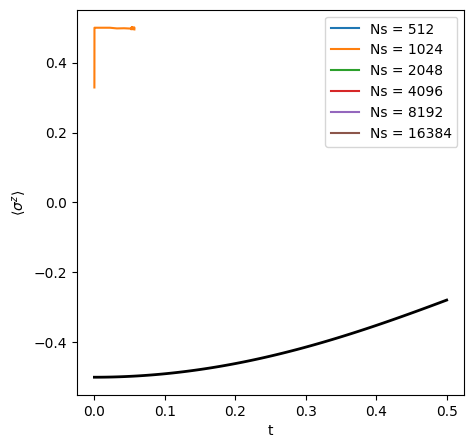

In [14]:
fig, ax_z = plt.subplots(1, 1, figsize=(5, 5))
for n_samples in n_samples_list:
    exp_name = f"bridge_{n_samples}"
    save_path = f"./data/TFIM_PFAFF/EPS_{N}/{exp_name}/"
    logger = Logger(path=save_path, fields=fields_to_track)
    print("Restored:", logger.restore())
    
    ax_z.plot(logger.data["t"]["values"], logger.data["sigma_z"]["Mean"], label = f"Ns = {n_samples}")
   
    ax_z.set_xlabel("t")
    ax_z.legend()
    ax_z.set_ylabel(r"$\langle\sigma^z \rangle$")
ax_z.plot(times_exact, np.real(magnetizations_exact), 'k-', linewidth=2, label='ED')